# Step 4c. Check the patches

Emmaus

**Look at the cubes before any model sees them. This is the most important checkpoint.**

- **Run after:** `build_patches.py`
- **Writes:**
  - `figures/patch_check_axial.png`: 10 rating-1 vs 10 rating-5 nodules, centre slice
  - `figures/patch_check_3views.png`: axial / coronal / sagittal through 4 nodules

**What right looks like:** every nodule sits dead centre. The 1s are small, round and smooth, or bright white (calcified). The 5s are bigger, irregular, spiky.

**What wrong looks like:** grey mush, nodules off-centre or missing, stretched in one direction (a spacing bug), or the same image twice.

Only train-split nodules are shown, so test stays unseen.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ct import NODULES, PATCH_DIR

SHOW_HU = (-1000, 400) # the same clip the model will get
C = 24 # centre voxel of a 48-cube

## Pick the nodules

10 nodules with median rating 1 and 10 with median rating 5, from the train split only.

In [2]:
nodules = pd.read_csv(NODULES)
train = nodules[nodules.split == "train"]
ones = train[train.hard == 1].sample(10, random_state=0)
fives = train[train.hard == 5].sample(10, random_state=0)

## Figure 1: centre axial slice of each cube

Top two rows are median 1, bottom two rows are median 5. The cyan lines cross at the cube centre, so the nodule should sit where they meet.

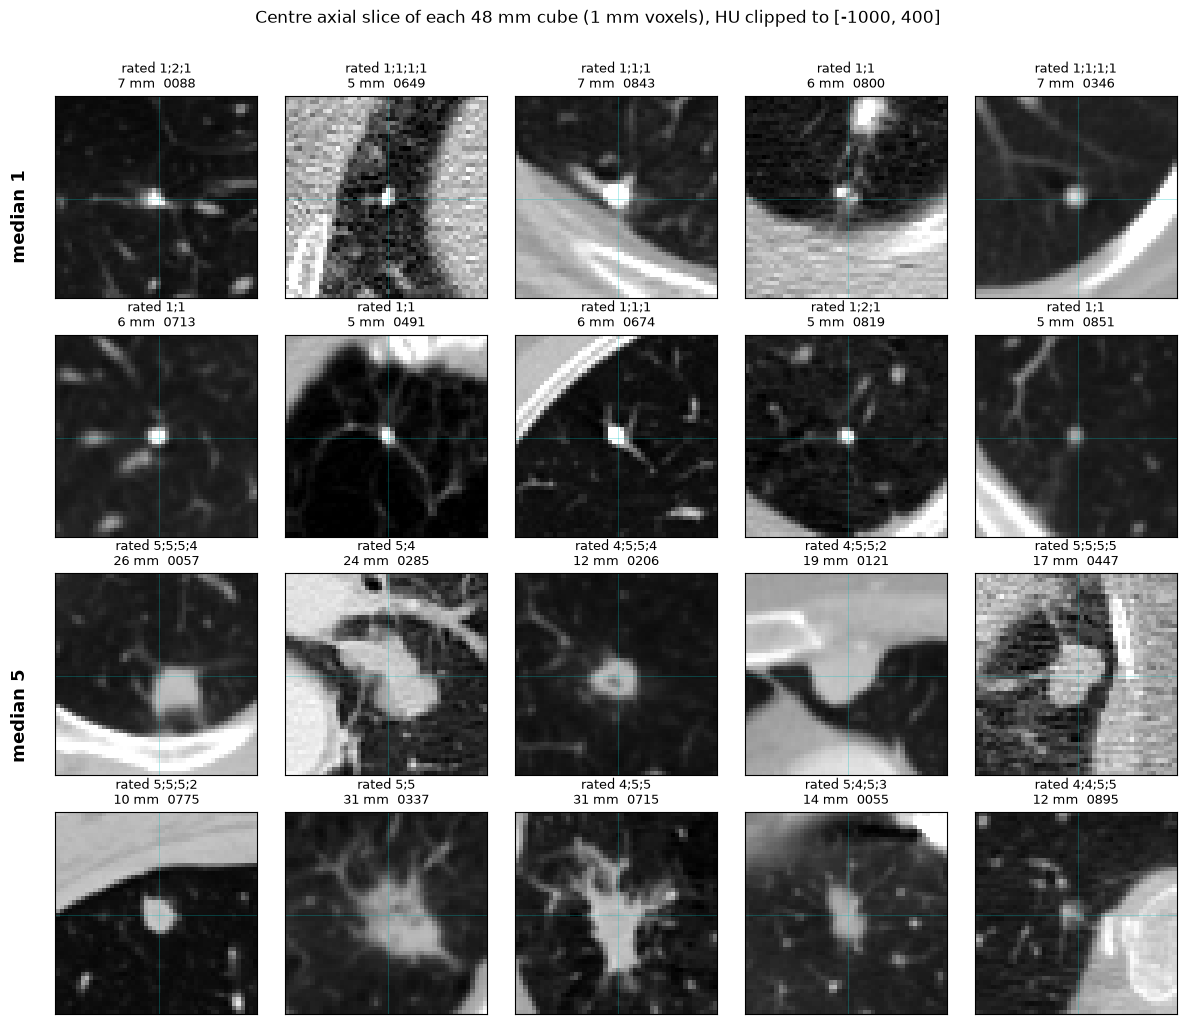

In [3]:
fig, axes = plt.subplots(4, 5, figsize=(12, 10.4))
for ax, (_, r) in zip(axes.flat, pd.concat([ones, fives]).iterrows()):
    cube = np.load(PATCH_DIR / r.patch_file)
    ax.imshow(cube[C], cmap="gray", vmin=SHOW_HU[0], vmax=SHOW_HU[1])
    ax.axhline(C, color="c", lw=0.4, alpha=0.5); ax.axvline(C, color="c", lw=0.4, alpha=0.5)
    ax.set_title(f"rated {r.ratings}\n{r.diameter_mm:.0f} mm  {r.patient_id[-4:]}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.text(0.01, 0.74, "median 1", rotation=90, fontsize=13, weight="bold")
fig.text(0.01, 0.26, "median 5", rotation=90, fontsize=13, weight="bold")
fig.suptitle("Centre axial slice of each 48 mm cube (1 mm voxels), HU clipped to [-1000, 400]")
fig.tight_layout(rect=(0.03, 0, 1, 0.97))
plt.show()

## Figure 2: three views through 4 nodules

The 2 smallest rating-1 nodules and the 2 largest rating-5 nodules from the sample above.

A nodule should not appear artificially stretched or compressed along the z-axis. **Squashed in coronal/sagittal = the z resampling is wrong.**

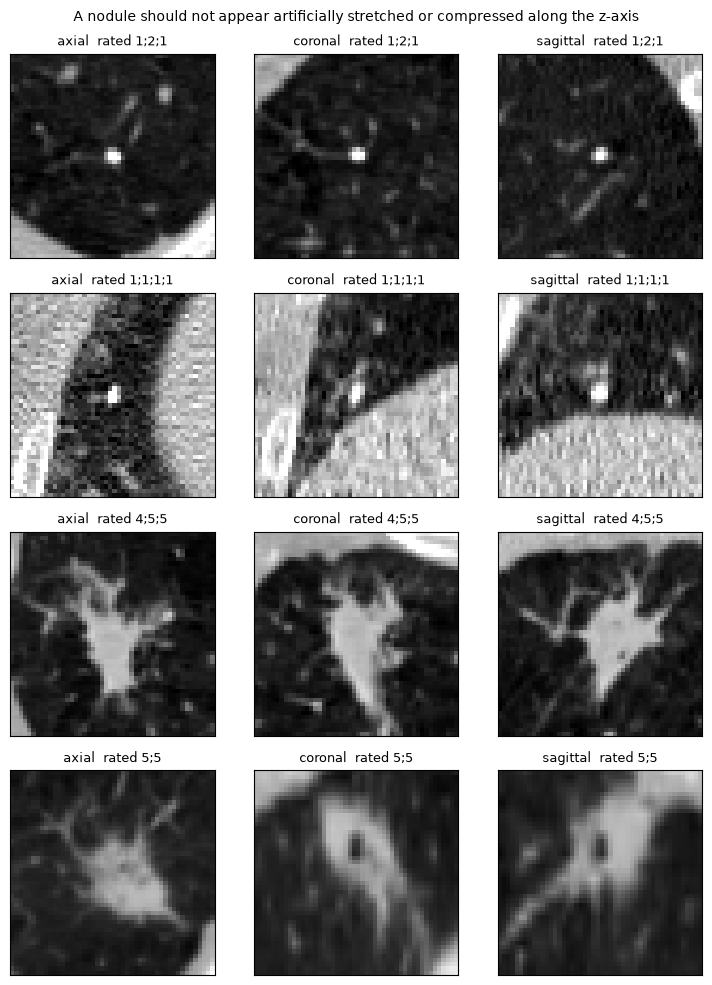

In [4]:
picks = pd.concat([ones.nsmallest(2, "diameter_mm"), fives.nlargest(2, "diameter_mm")])
fig, axes = plt.subplots(4, 3, figsize=(7.5, 10))
for row, (_, r) in zip(axes, picks.iterrows()):
    cube = np.load(PATCH_DIR / r.patch_file)
    # z runs inferior -> superior, so flip it to put the head at the top
    views = [cube[C], cube[::-1, C, :], cube[::-1, :, C]]
    for ax, img, name in zip(row, views, ["axial", "coronal", "sagittal"]):
        ax.imshow(img, cmap="gray", vmin=SHOW_HU[0], vmax=SHOW_HU[1])
        ax.set_title(f"{name}  rated {r.ratings}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("A nodule should not appear artificially stretched or compressed along the z-axis", fontsize=10)
fig.tight_layout()
plt.show()